In [9]:
from typing import TypedDict,List,Literal,Optional

class ApprovalState(TypedDict):
    action_details : str
    status : Optional[Literal["Pending","Approved","Rejected"]]

In [10]:
from langgraph.types import Command, interrupt
#create a node
def approval_node(state: ApprovalState) -> Command[Literal["proceed_node","cancel_node"]]:
    decision = interrupt(
        {
            "question" : "Approve this action?",
            "details" : state["action_details"],
        }
    )

    #Route to the appropriate node after resume
    return Command(goto="proceed_node" if decision else "cancel_node")

#create a proceed node
def proceed_node(state: ApprovalState):
    return {"status" : "Approved"}

#create a cancle node
def cancel_node(state: ApprovalState):
    return {"status" : "Rejected"}

In [11]:
#Create a state graph

from langgraph.graph import StateGraph,START,END

graph = StateGraph(ApprovalState)

graph.add_node("approval_node",approval_node)
graph.add_node("proceed_node",proceed_node)
graph.add_node("cancel_node",cancel_node)

graph.add_edge(START,"approval_node")
graph.add_edge("proceed_node",END)
graph.add_edge("cancel_node",END)

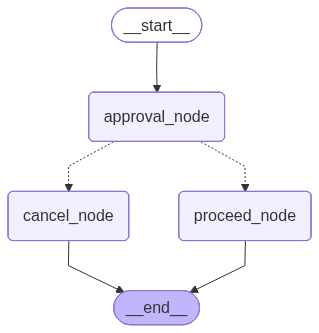

In [12]:
#compile the graph
#compile the graph
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import  display,Image

checkpointer = InMemorySaver()
memory_graph = graph.compile(checkpointer=checkpointer)

Image(memory_graph.get_graph().draw_mermaid_png())


In [13]:
#run the graph 
config = {"configurable" : {"thread_id" : "approve_123"}}
initial = memory_graph.invoke(
    {"action_details" : "Send daily summary","status" : "Pending"},
    config = config,
)
print(initial["__interrupt__"])

[Interrupt(value={'question': 'Approve this action?', 'details': 'Send daily summary'}, id='876b3794fbdd5ec7d17099a56b8b1f26')]


In [14]:
#approve or reject

resumed = memory_graph.invoke(Command(resume=True),config=config)
print(resumed["status"])

Approved
